# sim_study_rippler

## preamble

In [1]:
# importing numpy
import numpy as np
from numpy import random

In [2]:
# importing plotting
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
%matplotlib inline

In [3]:
# importing storage for results
import zarr

In [4]:
# importing pandas
import pandas as pd

In [5]:
# importing tensorflow probability
import tensorflow_probability as tfp

## simulated data

In [6]:
# loading in functions for simulation
%run '../../function_scripts_2/model/UC_simulation.py'

In [7]:
# importing the csv - only the important columns
data_real = pd.read_csv("../../Antidote_household.csv", usecols=["hid","pid","date","age","sex","hiv","hivChild","cpt","result","week"])

# converting the pid to integers (and saving lists of sex and age)
pid_unique = []
no_individuals = 0
test_individuals = []
sex = []
age = []
for i in range(1659):
    pid = data_real['pid'][i]
    if pid in pid_unique:
        test_individuals.append(pid_unique.index(pid))
    else:
        pid_unique.append(pid)
        test_individuals.append(no_individuals)
        sex.append(data_real['sex'][i])
        age.append(data_real['age'][i])
        no_individuals += 1
sex = np.array(sex)
age = np.array(age)

# centring age and sex
age = age - np.mean(age)
sex = sex - np.mean(sex)

# calculating N and T
N = no_individuals
T = int(max(data_real['week']))

# making a test result matrix (for the real test results)
test_results_real = np.tile(np.nan,(T+1,N))
for i in range(1659):
    j = test_individuals[i]
    t = int(data_real['week'][i])
    test_results_real[t,j] = data_real['result'][i]

# converting the hid to integers
hid_unique = []
no_houses = 0
test_houses = []
for hid in data_real['hid'] :
    if hid in hid_unique:
        test_houses.append(hid_unique.index(hid))
    else:
        hid_unique.append(hid)
        test_houses.append(no_houses)
        no_houses += 1

# list of which house each individual is in
house_list = []
for i in range(N):
    test_no = test_individuals.index(i)
    house_list.append(test_houses[test_no])

# making a household mixing matrix
h = np.zeros((N,N))
for i in range(N):
    for j in range(N):
        if house_list[i]==house_list[j]:
            h[i,j] = 1

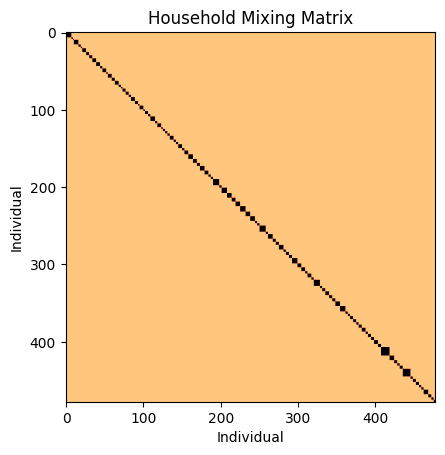

In [8]:
# plotting h
plt.imshow(h,cmap="copper_r")
plt.title("Household Mixing Matrix")
plt.ylabel("Individual")
plt.xlabel("Individual")
plt.show()

In [9]:
# true values of the paramters
theta = np.array([0.1,1.5,0,0])

In [10]:
# true values of other inputs
prop_0 = 0.3
gamma = 0.5
test_rate = 0.3 #will be replaced with other test data, but parameter needed for simulation
sens = 0.95
spec = 0.99

In [11]:
# seasonality modifiers
seasonality_mode = 2
seasonal_period = 52
t_ast = 17

# resulting matrices
seasonal_vector = np.array([1 - np.cos(2*np.pi*(t+t_ast)/seasonal_period) for t in range(T+1)])
seasonal_matrix_G = np.tile(seasonal_vector, (N,1)).T
seasonal_matrix_H = np.tile(1, (T+1,N))

In [12]:
# simulating the data
UC_results = UC_sim(N,h,age,sex,prop_0,theta,gamma,test_rate,sens,spec,T,seasonality_mode,seasonal_period,t_ast,1)

In [13]:
# creating a test result matrix
random.seed(256)
test_occurance = test_results_real*0 + 1
pos_prob = sens*UC_results['X'] + (1-spec)*(1-UC_results['X'])
test_outcome = random.binomial(1,pos_prob)
test_results = test_outcome * test_occurance

/tmp/ipykernel_3475747/1869204714.py:5: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour0, label="%d"%0, linestyle='', marker="s")
/tmp/ipykernel_3475747/1869204714.py:7: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour1, label="%d"%1, linestyle='', marker="s")


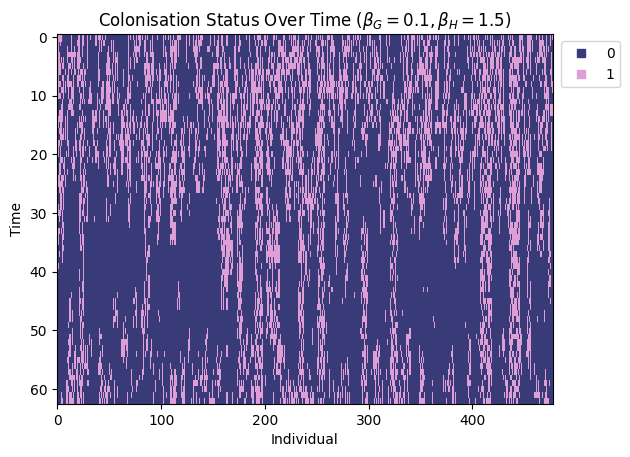

In [14]:
# plotting X
plt.imshow(UC_results['X'],cmap="tab20b",interpolation="nearest",aspect="auto")
#plt.colorbar()
colour0 = '#393b79'
plt.plot(0, 0, "-", color=colour0, label="%d"%0, linestyle='', marker="s")
colour1 = '#de9ed6'
plt.plot(0, 0, "-", color=colour1, label="%d"%1, linestyle='', marker="s")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0), scatterpoints=1)
plt.title(r'Colonisation Status Over Time ($\beta_G=0.1, \beta_H=1.5$)')
plt.ylabel("Time")
plt.xlabel("Individual")
plt.show()

/tmp/ipykernel_3475747/317312983.py:4: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour0, label="0", linestyle='', marker="s")
/tmp/ipykernel_3475747/317312983.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour1, label="1", linestyle='', marker="s")
/tmp/ipykernel_3475747/317312983.py:8: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(0, 0, "-", color=colour2, label="NA", linestyle='', marker="s")


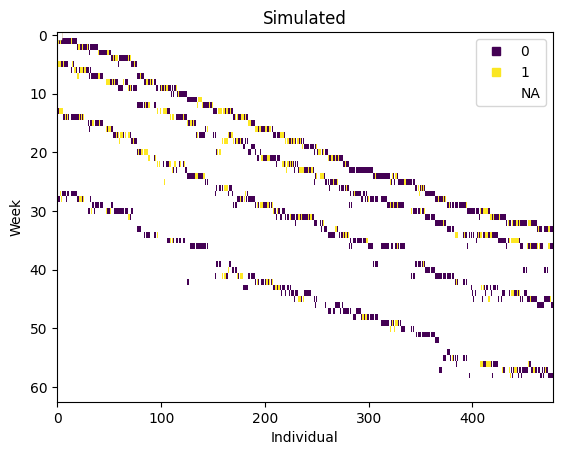

In [15]:
# looking at the test result matrix
plt.imshow(test_results,cmap="viridis",interpolation="nearest",aspect="auto")
colour0 = '#440154'
plt.plot(0, 0, "-", color=colour0, label="0", linestyle='', marker="s")
colour1 = '#fae622'
plt.plot(0, 0, "-", color=colour1, label="1", linestyle='', marker="s")
colour2 = '#ffffff'
plt.plot(0, 0, "-", color=colour2, label="NA", linestyle='', marker="s")
plt.legend(loc="upper right", scatterpoints=1)
plt.title(r'Simulated')
plt.ylabel("Week")
plt.xlabel("Individual")
#plt.savefig("plots/test_results_sim.pdf")
plt.show()

In [16]:
# function to work out the number of TP/FP/TN/FNs
def test_acc(X:np.array,test_results:np.array) :
    
    # list of inputs:
    # X - matrix of all individuals colonisation status over time
    # test_results - matrix of all individuals colonisation status over time

    # creating a matrix comparing the results with the current latent variable values (0 for TPs or TNs, 1 for FPs, -1 for FNs, and nan for no tests)
    test_diff_matrix = test_results - X

    # calculating the number of TP/FP/TN/FNs from this matrix
    TP = np.sum((test_diff_matrix==0)*X)
    FN = np.sum(test_diff_matrix==-1)
    FP = np.sum(test_diff_matrix==1)
    TN = np.sum((test_diff_matrix==0)*(1-X))

    # returning outputs
    output = {'TP':TP, 'FN':FN, 'FP':FP, 'TN':TN}
    return output

In [17]:
# the number of TP/FP/TN/FNs
test_acc(UC_results['X'],test_results)

{'TP': 383, 'FN': 17, 'FP': 16, 'TN': 1157}

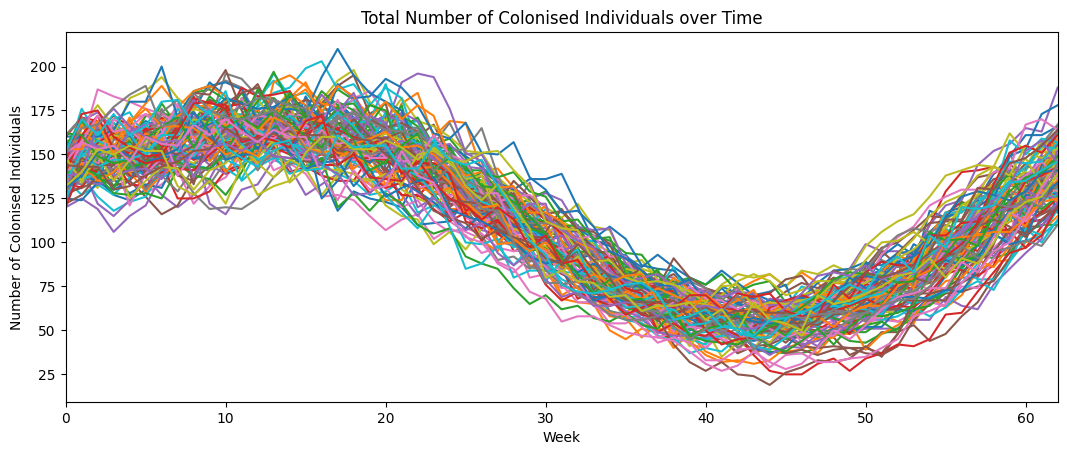

In [80]:
# many simulations
plt.figure(figsize=(12.8,4.8))
for i in range(100):
    UC_results_i = UC_sim(N,h,age,sex,prop_0,theta,gamma,test_rate,sens,spec,T,seasonality_mode,seasonal_period,t_ast,i)
    plt.plot(UC_results_i['sum_C'])
plt.title("Total Number of Colonised Individuals over Time")
plt.ylabel("Number of Colonised Individuals")
plt.xlabel("Week")
plt.xlim(0,62)
plt.savefig("plots/sim_colonised.pdf")
plt.show()

## inference information

In [29]:
# hyperparameters of priors
mu = np.array([0.001,0.001,0.001,0.001])
prior_X_0 = 0.3

In [30]:
# starting values
theta_start = np.array([0.5,0.5,0,0])
X_start = UC_sim(N,h,age,sex,prop_0,theta,gamma,test_rate,sens,spec,T,seasonality_mode,seasonal_period,t_ast,1)['X']
covariance_start = 0.8*0.000001*np.identity(4)
scaling = 0.8

In [31]:
# MCMC iterations
K = 11000
K_latent = 400

## acceptance rates

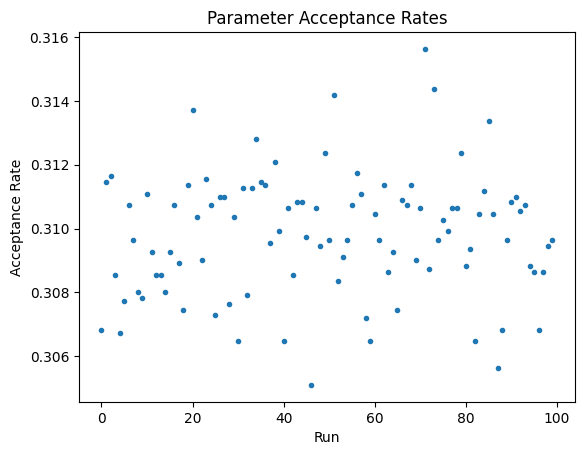

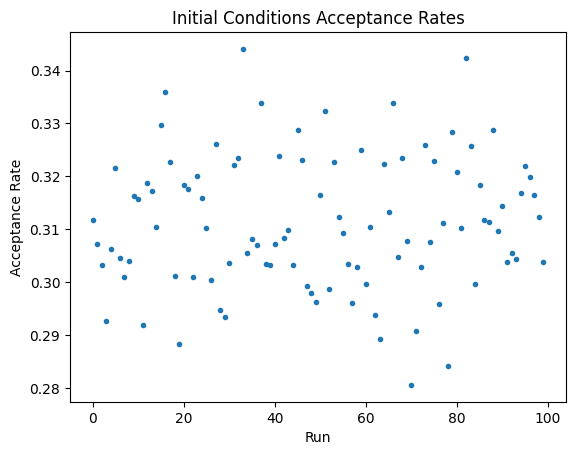

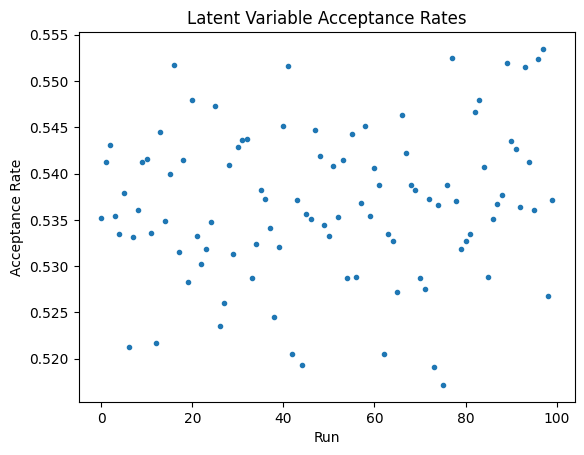

In [40]:
# empty arrays
acc_theta = np.zeros(100)
acc_initial = np.zeros(100)
acc_latent = np.zeros(100)

# importing the saved acceptance rates for all the runs
for i in range(100):

    # repeat number string
    if i < 10:
        repeat_num = '0'+str(i)
    else:
        repeat_num = str(i)

    # importing the saved acceptance rates
    MCMC_noncentred_acc = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_many/MCMC_output_'+repeat_num+'/acc.zarr', mode='r')

    # printing the acceptance rates
    acc_theta[i] =  MCMC_noncentred_acc[0]
    acc_initial[i] =  MCMC_noncentred_acc[1]
    acc_latent[i] =  MCMC_noncentred_acc[2]

    # removing the acceptance rates from memory
    del(MCMC_noncentred_acc)

# plotting
plt.plot(acc_theta,'.')
plt.xlabel('Run')
plt.ylabel('Acceptance Rate')
plt.title('Parameter Acceptance Rates')
plt.show()
plt.plot(acc_initial,'.')
plt.xlabel('Run')
plt.ylabel('Acceptance Rate')
plt.title('Initial Conditions Acceptance Rates')
plt.show()
plt.plot(acc_latent,'.')
plt.xlabel('Run')
plt.ylabel('Acceptance Rate')
plt.title('Latent Variable Acceptance Rates')
plt.show()

## parameters

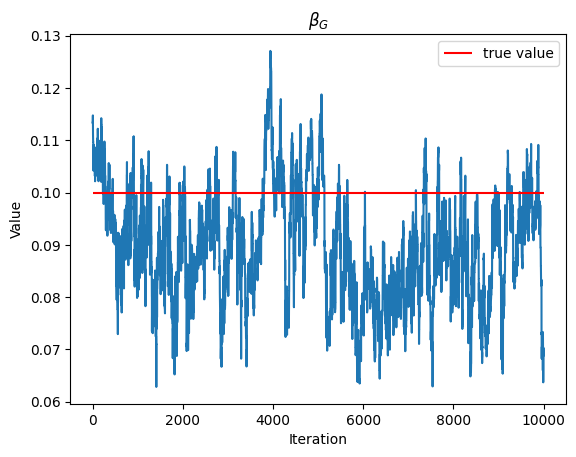

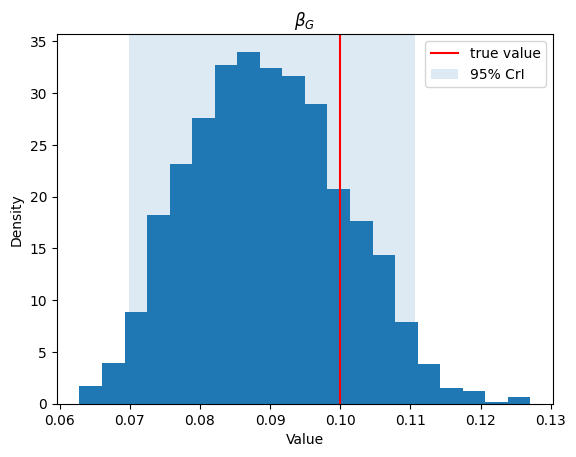

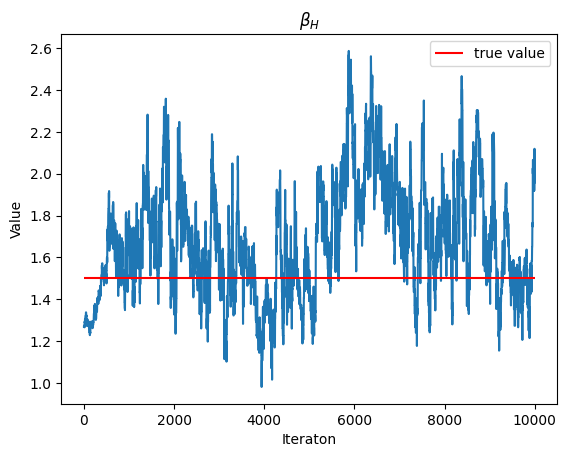

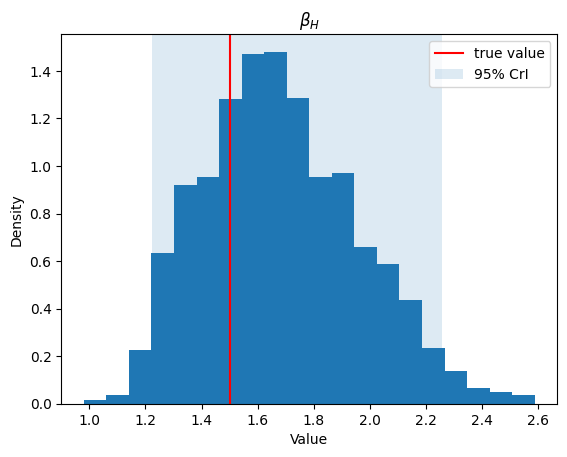

beta_G: [0.06996397 0.08929518 0.11065897]
beta_H: [1.22416098 1.65771642 2.25620492]


In [48]:
# importing the saved run of theta
MCMC_noncentred_theta = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_many/MCMC_output_64/theta.zarr', mode='r')

# trace plot and histogram of beta_G
plt.plot(MCMC_noncentred_theta[1000:,0])
plt.hlines(np.array(theta[0]),0,K-1000,colors="red",label="true value")
plt.legend(loc = "upper right")
plt.title(r'$\beta_G$')
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.show()
plt.hist(MCMC_noncentred_theta[1000:,0],density=1,bins=20)
plt.axvline(theta[0],color="red",label="true value")
plt.axvspan(np.quantile(MCMC_noncentred_theta[1000:,0],0.025),np.quantile(MCMC_noncentred_theta[1000:,0],0.975),alpha=0.15,label="95% CrI")
plt.legend(loc = "upper right")
plt.title(r'$\beta_G$')
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

# trace plot and histogram of beta_H
plt.plot(MCMC_noncentred_theta[1000:,1])
plt.hlines(np.array(theta[1]),0,K-1000,colors="red",label="true value")
plt.legend()
plt.title(r'$\beta_{H}$')
plt.xlabel("Iteraton")
plt.ylabel("Value")
plt.show()
plt.hist(MCMC_noncentred_theta[1000:,1],density=1,bins=20)
plt.axvline(theta[1],color="red",label="true value")
plt.axvspan(np.quantile(MCMC_noncentred_theta[1000:,1],0.025),np.quantile(MCMC_noncentred_theta[1000:,1],0.975),alpha=0.15,label="95% CrI")
plt.legend()
plt.title(r'$\beta_{H}$')
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

# median and 95% credible intervals
print("beta_G:", np.quantile(MCMC_noncentred_theta[1000:,0],[0.025,0.5,0.975]))
print("beta_H:", np.quantile(MCMC_noncentred_theta[1000:,1],[0.025,0.5,0.975]))

# removing the traces of theta from memory
del(MCMC_noncentred_theta)

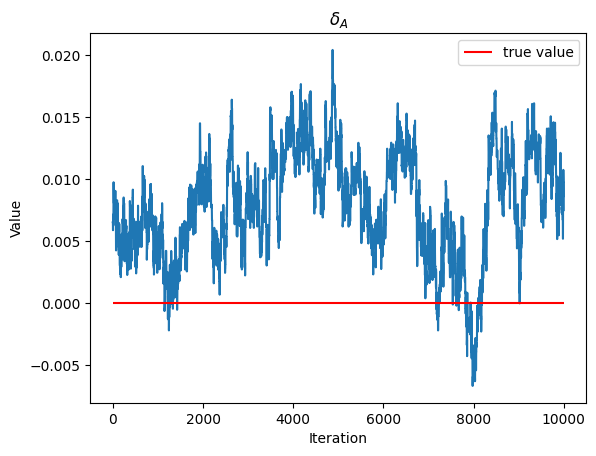

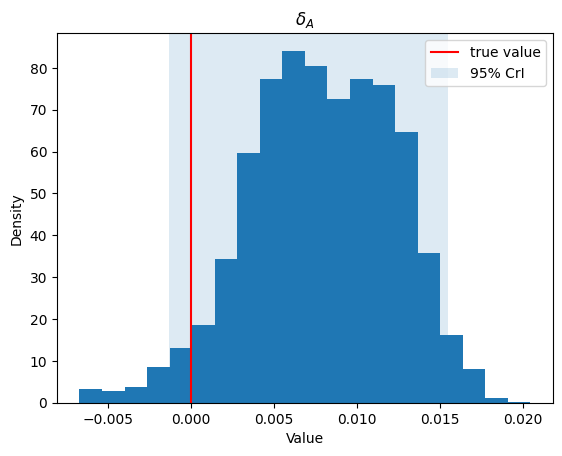

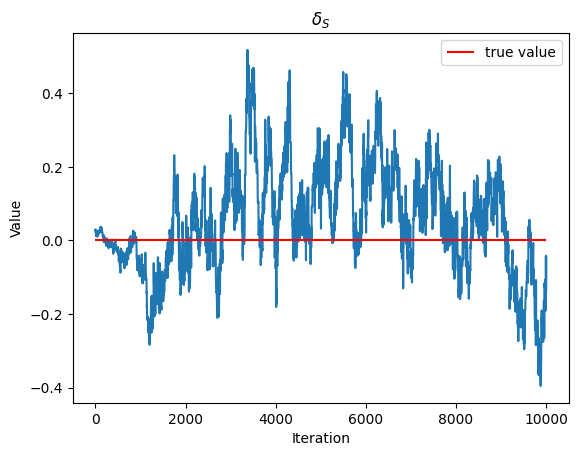

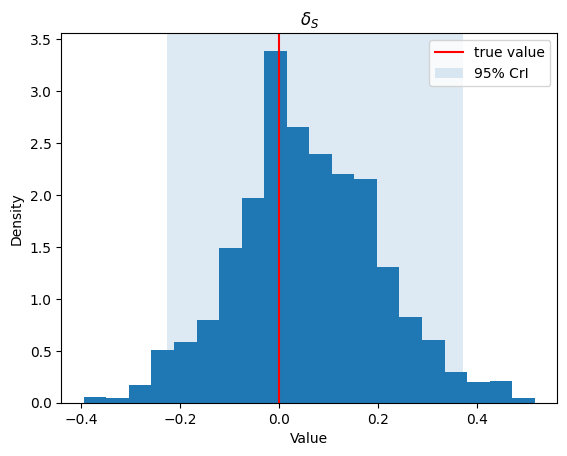

delta_A: [-0.00128821  0.00788868  0.01549061]
delta_S: [-0.22633611  0.0476529   0.37197618]


In [47]:
# importing the saved run of theta
MCMC_noncentred_theta = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_many/MCMC_output_64/theta.zarr', mode='r')

# trace plot and histogram of delta_A
plt.plot(MCMC_noncentred_theta[1000:,2])
plt.hlines(np.array(theta[2]),0,K-1000,colors="red",label="true value")
plt.legend()
plt.title(r'$\delta_A$')
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.show()
plt.hist(MCMC_noncentred_theta[1000:,2],density=1,bins=20)
plt.axvline(theta[2],color="red",label="true value")
plt.axvspan(np.quantile(MCMC_noncentred_theta[1000:,2],0.025),np.quantile(MCMC_noncentred_theta[1000:,2],0.975),alpha=0.15,label="95% CrI")
plt.legend(loc='upper right')
plt.title(r'$\delta_A$')
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

# trace plot and histogram of delta_S
plt.plot(MCMC_noncentred_theta[1000:,3])
plt.hlines(np.array(theta[3]),0,K-1000,colors="red",label="true value")
plt.legend()
plt.title(r'$\delta_S$')
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.show()
plt.hist(MCMC_noncentred_theta[1000:,3],density=1,bins=20)
plt.axvline(theta[3],color="red",label="true value")
plt.axvspan(np.quantile(MCMC_noncentred_theta[1000:,3],0.025),np.quantile(MCMC_noncentred_theta[1000:,3],0.975),alpha=0.15,label="95% CrI")
plt.legend(loc='upper right')
plt.title(r'$\delta_S$')
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

# median and 95% credible intervals
print("delta_A:", np.quantile(MCMC_noncentred_theta[1000:,2],[0.025,0.5,0.975]))
print("delta_S:", np.quantile(MCMC_noncentred_theta[1000:,3],[0.025,0.5,0.975]))

# removing the traces of theta from memory
del(MCMC_noncentred_theta)

In [49]:
# empty arrays
theta_quantiles = np.zeros((100,4,3))

# importing the parameters for all the runs
for i in range(100):

    # repeat number string
    if i < 10:
        repeat_num = '0'+str(i)
    else:
        repeat_num = str(i)

    # importing the saved run of theta
    MCMC_noncentred_theta = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_many/MCMC_output_'+repeat_num+'/theta.zarr', mode='r')

    # median and 95% credible intervals
    theta_quantiles[i,0] = np.quantile(MCMC_noncentred_theta[1000:,0],[0.025,0.5,0.975])
    theta_quantiles[i,1] = np.quantile(MCMC_noncentred_theta[1000:,1],[0.025,0.5,0.975])
    theta_quantiles[i,2] = np.quantile(MCMC_noncentred_theta[1000:,2],[0.025,0.5,0.975])
    theta_quantiles[i,3] = np.quantile(MCMC_noncentred_theta[1000:,3],[0.025,0.5,0.975])

    # removing the traces of theta from memory
    del(MCMC_noncentred_theta)

In [69]:
# how many 95% credible intervals contain the true value?
print("beta_G:", np.sum((theta_quantiles[:,0,0] < theta[0]) * (theta_quantiles[:,0,2] > theta[0])))
print("beta_H:", np.sum((theta_quantiles[:,1,0] < theta[1]) * (theta_quantiles[:,1,2] > theta[1])))
print("delta_A:", np.sum((theta_quantiles[:,2,0] < theta[2]) * (theta_quantiles[:,2,2] > theta[2])))
print("delta_S:", np.sum((theta_quantiles[:,3,0] < theta[3]) * (theta_quantiles[:,3,2] > theta[3])))

beta_G: 95
beta_H: 93
delta_A: 89
delta_S: 99


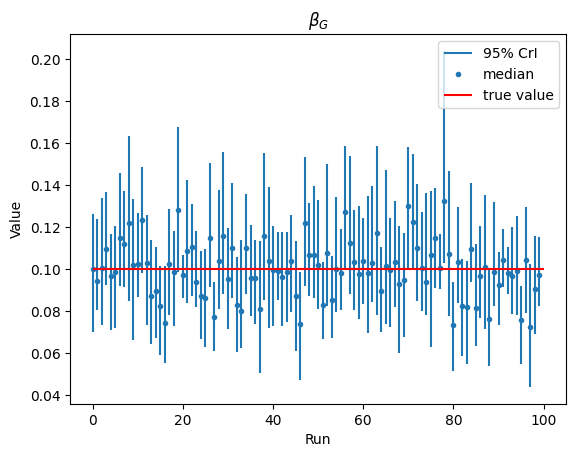

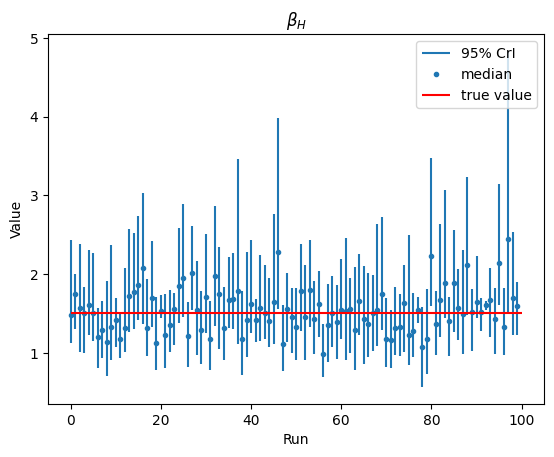

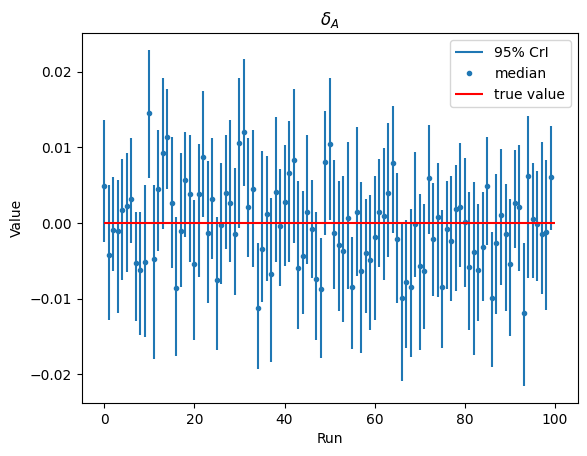

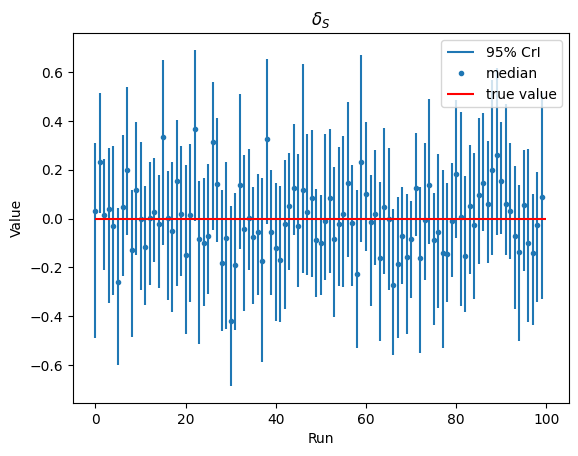

In [78]:
# plotting the theta quantiles
plt.vlines(range(100),theta_quantiles[:,0,0],theta_quantiles[:,0,2],label="95% CrI")
plt.plot(theta_quantiles[:,0,1],'.',label="median",color="tab:blue")
plt.hlines(np.array(theta[0]),0,100,colors="red",label="true value")
plt.legend()
plt.xlabel("Run")
plt.ylabel("Value")
plt.title(r'$\beta_G$')
plt.savefig("plots/beta_G_runs.pdf")
plt.show()
plt.vlines(range(100),theta_quantiles[:,1,0],theta_quantiles[:,1,2],label="95% CrI")
plt.plot(theta_quantiles[:,1,1],'.',label="median",color="tab:blue")
plt.hlines(np.array(theta[1]),0,100,colors="red",label="true value")
plt.legend()
plt.xlabel("Run")
plt.ylabel("Value")
plt.title(r'$\beta_H$')
plt.savefig("plots/beta_H_runs.pdf")
plt.show()
plt.vlines(range(100),theta_quantiles[:,2,0],theta_quantiles[:,2,2],label="95% CrI")
plt.plot(theta_quantiles[:,2,1],'.',label="median",color="tab:blue")
plt.hlines(np.array(theta[2]),0,100,colors="red",label="true value")
plt.legend()
plt.xlabel("Run")
plt.ylabel("Value")
plt.title(r'$\delta_A$')
plt.savefig("plots/delta_A_runs.pdf")
plt.show()
plt.vlines(range(100),theta_quantiles[:,3,0],theta_quantiles[:,3,2],label="95% CrI")
plt.plot(theta_quantiles[:,3,1],'.',label="median",color="tab:blue")
plt.hlines(np.array(theta[3]),0,100,colors="red",label="true value")
plt.legend()
plt.xlabel("Run")
plt.ylabel("Value")
plt.title(r'$\delta_S$')
plt.savefig("plots/delta_S_runs.pdf")
plt.show()

## latent variables

In [72]:
# importing the saved run of the X matrices resulting from the latent variables
MCMC_noncentred_X = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_many/MCMC_output_64/X.zarr', mode='r')

# finding the quantiles
quantile_array = np.zeros((T+1,3))
for t in range(T+1):
    #print(t)
    quantile_array[t] = np.quantile(np.sum(MCMC_noncentred_X[1000:,t,:],axis=-1),[0.025,0.5,0.975])

# removing the traces of the latent variables from memory
del(MCMC_noncentred_X)

In [73]:
# importing the saved run of the X matrices resulting from the latent variables
MCMC_noncentred_X = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_many/MCMC_output_64/X.zarr', mode='r')

# picking a random MCMC iteration
random.seed(123)
iterations = random.randint(1000,K,5)
print(iterations)
random_path_0 = np.sum(MCMC_noncentred_X[iterations[0],:,:],axis=-1)
random_path_1 = np.sum(MCMC_noncentred_X[iterations[1],:,:],axis=-1)
random_path_2 = np.sum(MCMC_noncentred_X[iterations[2],:,:],axis=-1)
random_path_3 = np.sum(MCMC_noncentred_X[iterations[3],:,:],axis=-1)
random_path_4 = np.sum(MCMC_noncentred_X[iterations[4],:,:],axis=-1)

# removing the traces of the latent variables from memory
del(MCMC_noncentred_X)

[ 4582  2346  6218  8763 10785]


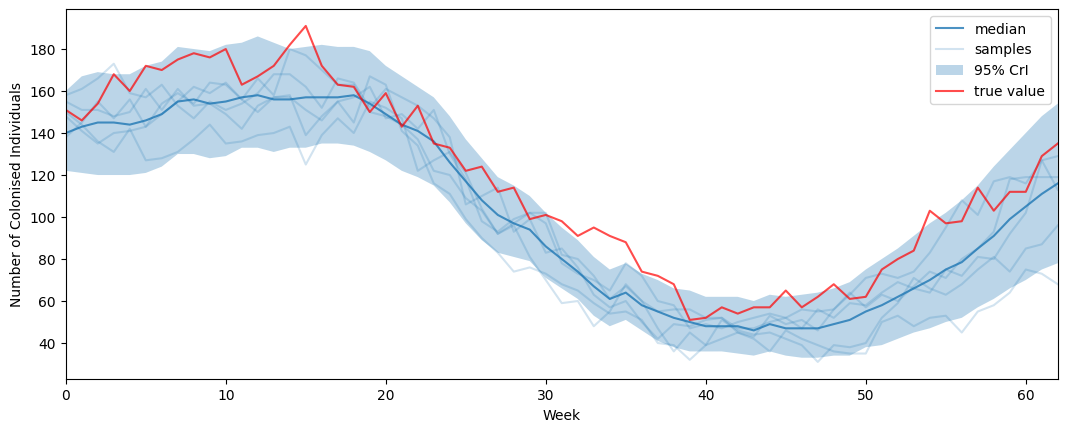

In [74]:
# 95% credible interval and median vs true (burn-in removed)
plt.figure(figsize=(12.8,4.8))
plt.plot(quantile_array[:,1], alpha=0.8, label="median")
plt.plot(random_path_0, alpha=0.2, color="tab:blue", label="samples")
plt.plot(random_path_1, alpha=0.2, color="tab:blue")
plt.plot(random_path_2, alpha=0.2, color="tab:blue")
plt.plot(random_path_3, alpha=0.2, color="tab:blue")
plt.plot(random_path_4, alpha=0.2, color="tab:blue")
plt.fill_between(range(T+1), quantile_array[:,0], quantile_array[:,2], alpha=0.3, label="95% CrI")
plt.plot(np.sum(UC_results['X'],axis=1), color="red", alpha=0.7, label="true value")
plt.legend(loc="upper right")
#plt.title("Number of Colonised Individuals")
plt.xlabel("Week")
plt.ylabel("Number of Colonised Individuals")
plt.xlim(0,62)
plt.show()

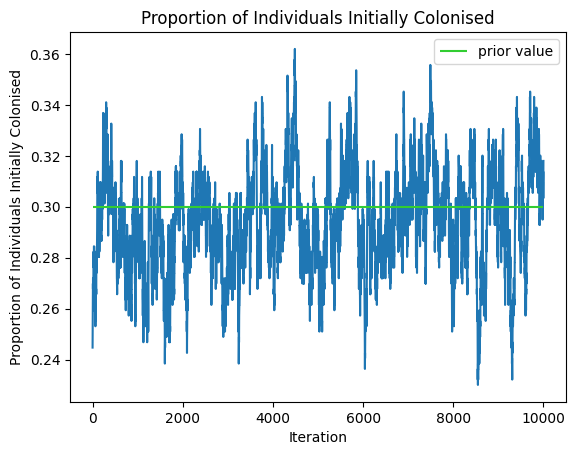

In [71]:
# importing the saved run of the X matrices resulting from the latent variables
MCMC_noncentred_X = zarr.open('../../../luna/AntiDOTE_Methods/experiments/sim_study_rippler_many/MCMC_output_64/X.zarr', mode='r')

# proportion of individuals colonised at time 0
plt.plot(np.average(MCMC_noncentred_X[1000:,0,:],axis=1))
plt.hlines(prior_X_0,0,K-1000,colors="limegreen",label="prior value")
plt.legend(loc = "upper right")
plt.title("Proportion of Individuals Initially Colonised")
plt.xlabel("Iteration")
plt.ylabel("Proportion of Individuals Initially Colonised")
plt.show()

# removing the traces of the latent variables from memory
del(MCMC_noncentred_X)

## end